In [ ]:
import marimo as mo

mo.md(
    """
    # Choosing `materialized` vs `matrix_free`

    A practical side-by-side run of the two training methods on the same local
    dataset. This is a correctness/equivalence smoke test: both routes should
    produce closely matching predictive means and uncertainty while using
    different backend execution paths.
    """
)

# Choosing `materialized` vs `matrix_free`

A practical side-by-side run of the two training methods on the same local
dataset. This is a correctness/equivalence smoke test: both routes should
produce closely matching predictive means and uncertainty while using
different backend execution paths.

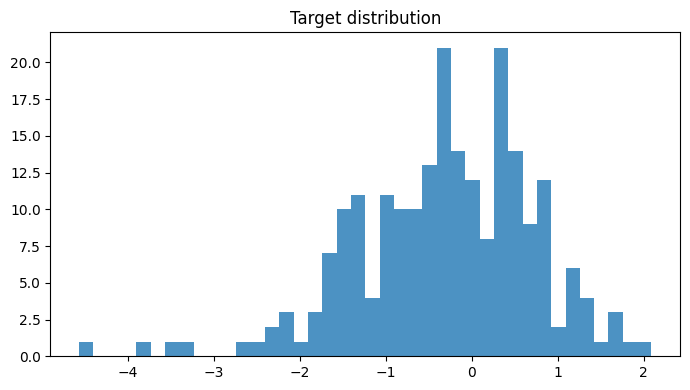

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(9)
X = rng.normal(size=(300, 5)).astype(np.float32)
y_latent = (
    np.sin(X[:, 0])
    + 0.5 * X[:, 1]
    - 0.4 * X[:, 2] ** 2
).astype(np.float32)
y = (
    y_latent
    + 0.15 * rng.standard_normal(300)
).astype(np.float32)
X_train, X_test = X[:220], X[220:]
y_train = y[:220]
y_latent_test = y_latent[220:]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_train, bins=40, alpha=0.8)
ax.set_title("Target distribution")
fig.tight_layout()
mo.mpl.interactive(fig)

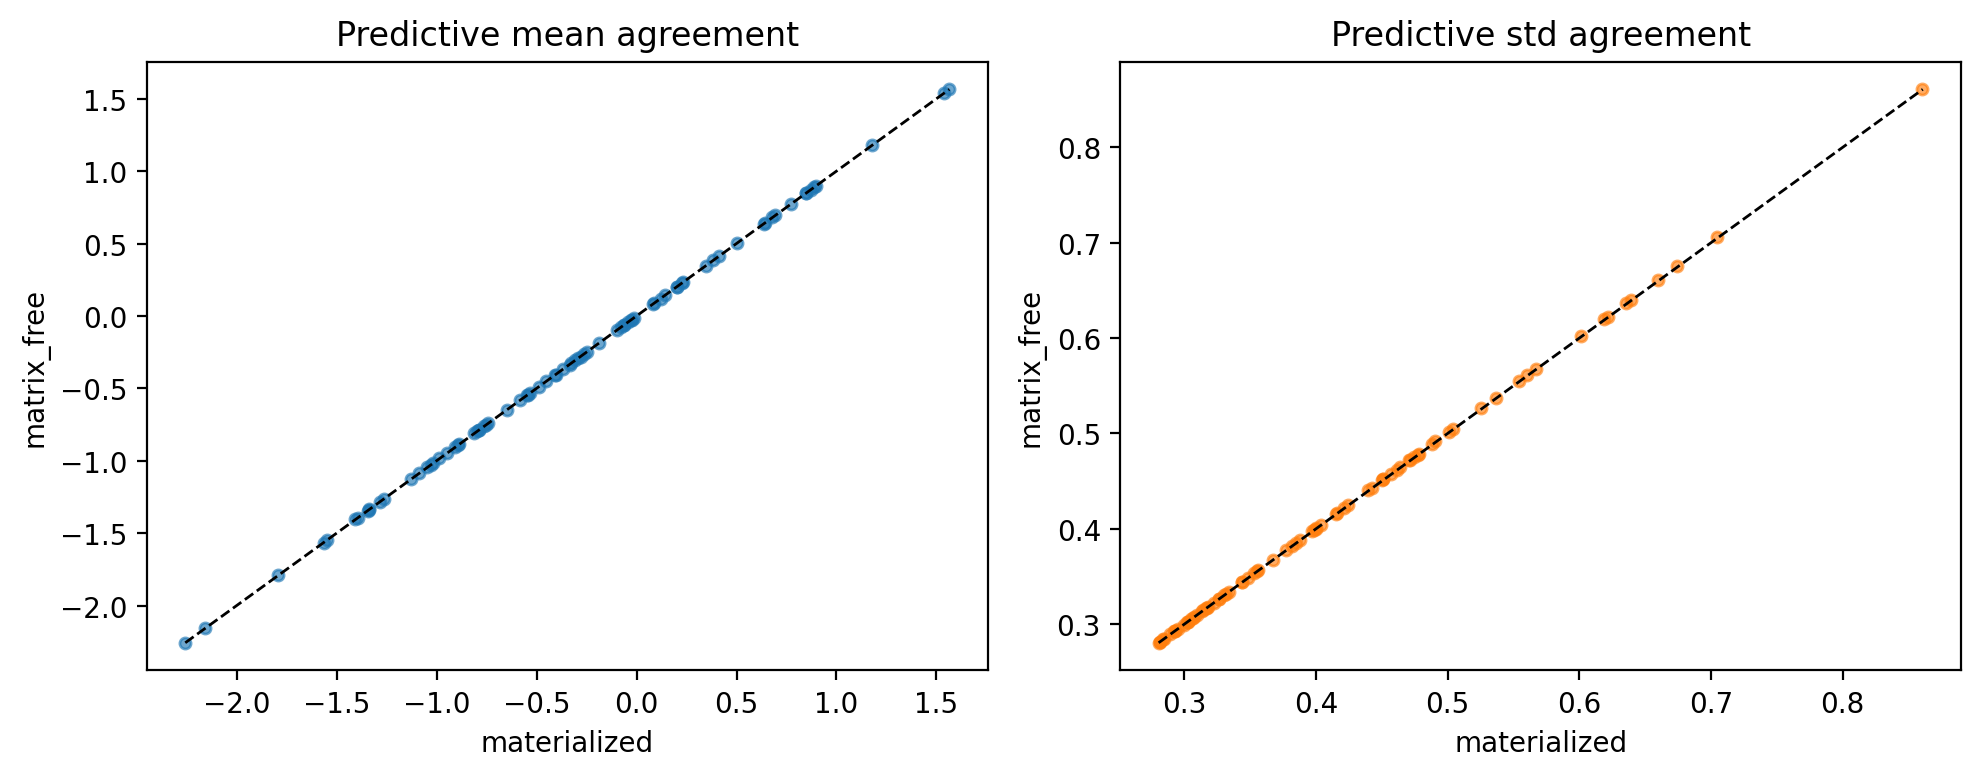

Results 
 The fit times are illustrative for this tiny notebook dataset, not a benchmark claim. The important check here is that both exact routes return nearly identical predictive means and uncertainty. <marimo-table data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">Route comparison</span></span>"' data-data='"[{\"Method\":\"materialized\",\"Train route\":\"materialized\",\"Variance method\":\"exact\",\"RMSE vs latent truth\":\"0.2964\",\"Mean predictive std\":\"0.4158\",\"95% latent coverage\":\"1.000\",\"Fit time (s)\":\"1.87\",\"Final NLL\":\"0.5325\"},{\"Method\":\"matrix_free\",\"Train route\":\"matrix_free\",\"Variance method\":\"exact\",\"RMSE vs latent truth\":\"0.2967\",\"Mean predictive std\":\"0.4163\",\"95% latent coverage\":\"1.000\",\"Fit time (s)\":\"0.16\",\"Final NLL\":\"0.5290\"}]"' data-total-rows='2' data-total-columns='8' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-selection='"multi"' data-show-filters='false' data-show-download='false' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> Route Equivalence Check 
 Use materialized when the train kernel matrix comfortably fits memory. Use matrix_free when you want the same wrapper API without storing the full train-train kernel. <marimo-table data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">Route equivalence check</span></span>"' data-data='"[{\"Quantity\":\"Max absolute mean difference\",\"Value\":\"0.002577\"},{\"Quantity\":\"RMS mean difference\",\"Value\":\"0.001149\"},{\"Quantity\":\"Max absolute std difference\",\"Value\":\"0.001259\"},{\"Quantity\":\"RMS std difference\",\"Value\":\"0.000569\"}]"' data-total-rows='4' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-selection='"multi"' data-show-filters='false' data-show-download='false' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'>
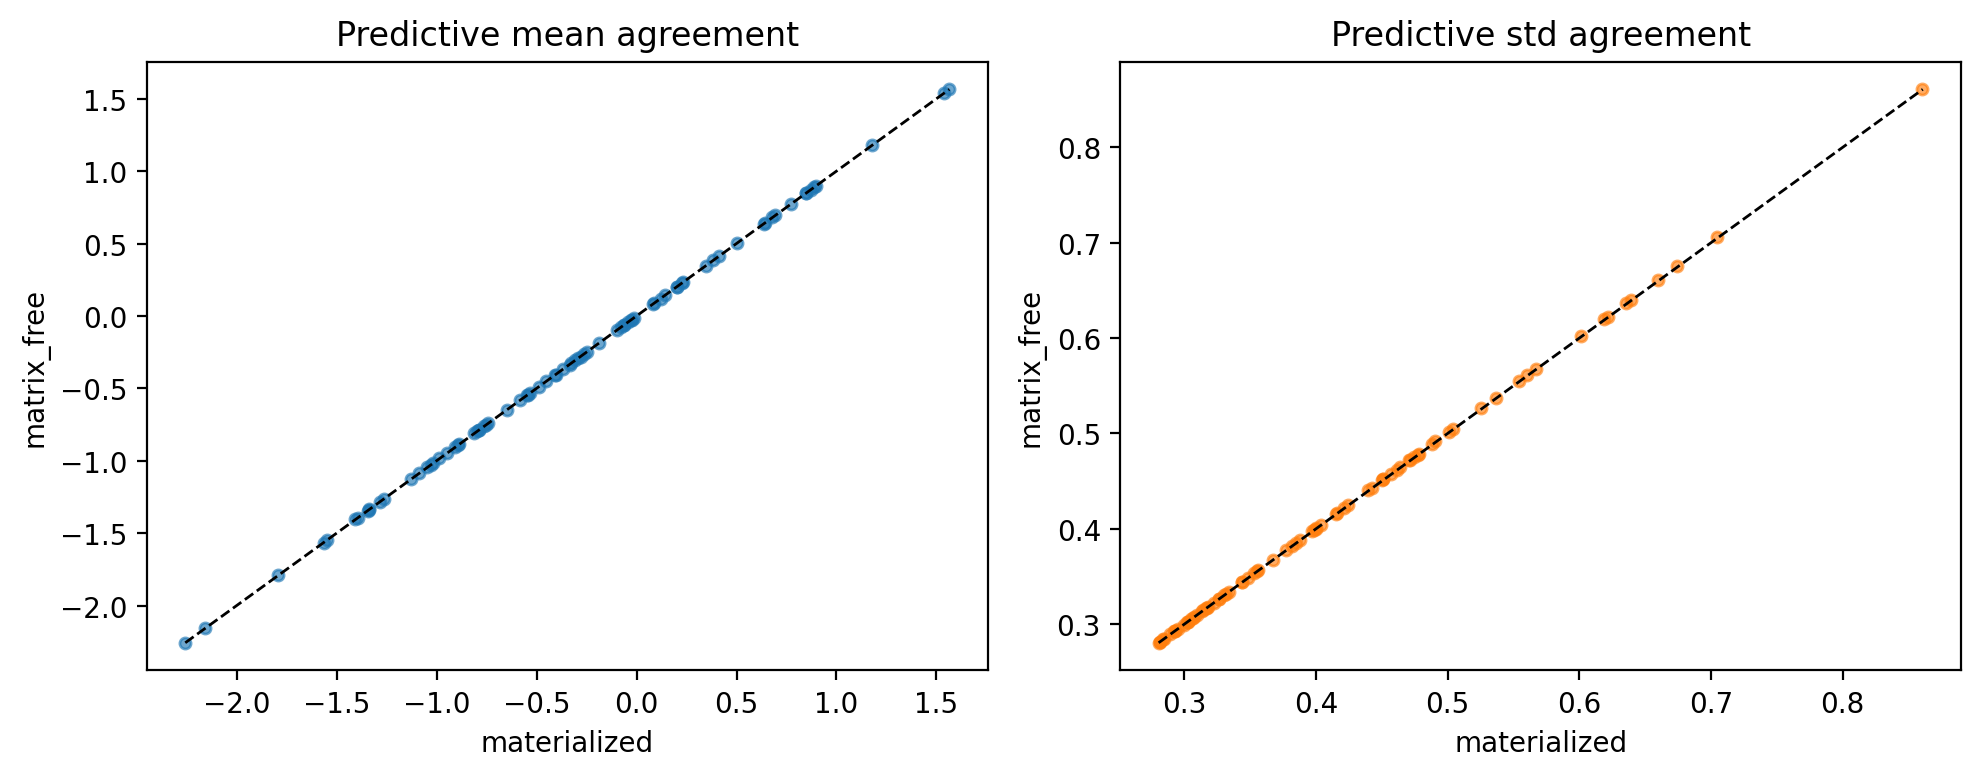

In [ ]:
import time
from mojogp import SingleOutputGP, RBF

rows = []
models = {}
for method in ("materialized", "matrix_free"):
    gp = SingleOutputGP(RBF(ard=True))
    t0 = time.perf_counter()
    result = gp.fit(
        X_train,
        y_train,
        max_iterations=15,
        learning_rate=0.035,
        method=method,
        progress=True,
    )
    elapsed = time.perf_counter() - t0
    prediction = gp.predict(X_test, variance_method="exact", progress=True)
    train_info = dict(gp.backend_train_info or {})
    predict_info = dict(gp.backend_predict_info or {})
    lower = prediction.mean - 2 * prediction.std
    upper = prediction.mean + 2 * prediction.std
    rows.append(
        {
            "method": method,
            "training_route": train_info.get("training_route", "n/a"),
            "variance_method": predict_info.get("variance_method", "n/a"),
            "exact_cross_mode": predict_info.get("exact_cross_mode", "n/a"),
            "rmse": float(np.sqrt(np.mean((prediction.mean - y_latent_test) ** 2))),
            "mean_std": float(np.mean(prediction.std)),
            "coverage": float(
                np.mean((y_latent_test >= lower) & (y_latent_test <= upper))
            ),
            "seconds": elapsed,
            "nll": result.nll,
        }
    )
    models[method] = {
        "gp": gp,
        "prediction": prediction,
        "train_info": train_info,
        "predict_info": predict_info,
    }

materialized_pred = models["materialized"]["prediction"]
matrix_free_pred = models["matrix_free"]["prediction"]
mean_diff = materialized_pred.mean - matrix_free_pred.mean
std_diff = materialized_pred.std - matrix_free_pred.std
max_abs_mean_diff = float(np.max(np.abs(mean_diff)))
rms_mean_diff = float(np.sqrt(np.mean(mean_diff ** 2)))
max_abs_std_diff = float(np.max(np.abs(std_diff)))
rms_std_diff = float(np.sqrt(np.mean(std_diff ** 2)))

results_table = [
    {
        "Method": row["method"],
        "Train route": row["training_route"],
        "Variance method": row["variance_method"],
        "RMSE vs latent truth": f"{row['rmse']:.4f}",
        "Mean predictive std": f"{row['mean_std']:.4f}",
        "95% latent coverage": f"{row['coverage']:.3f}",
        "Fit time (s)": f"{row['seconds']:.2f}",
        "Final NLL": f"{row['nll']:.4f}",
    }
    for row in rows
]
equivalence_table = [
    {"Quantity": "Max absolute mean difference", "Value": f"{max_abs_mean_diff:.6f}"},
    {"Quantity": "RMS mean difference", "Value": f"{rms_mean_diff:.6f}"},
    {"Quantity": "Max absolute std difference", "Value": f"{max_abs_std_diff:.6f}"},
    {"Quantity": "RMS std difference", "Value": f"{rms_std_diff:.6f}"},
]

fig_compare, compare_axes = plt.subplots(1, 2, figsize=(10, 4))
compare_axes[0].scatter(
    materialized_pred.mean,
    matrix_free_pred.mean,
    s=16,
    alpha=0.65,
    color="tab:blue",
)
mean_min = float(min(materialized_pred.mean.min(), matrix_free_pred.mean.min()))
mean_max = float(max(materialized_pred.mean.max(), matrix_free_pred.mean.max()))
compare_axes[0].plot([mean_min, mean_max], [mean_min, mean_max], "k--", linewidth=1)
compare_axes[0].set_title("Predictive mean agreement")
compare_axes[0].set_xlabel("materialized")
compare_axes[0].set_ylabel("matrix_free")

compare_axes[1].scatter(
    materialized_pred.std,
    matrix_free_pred.std,
    s=16,
    alpha=0.65,
    color="tab:orange",
)
std_min = float(min(materialized_pred.std.min(), matrix_free_pred.std.min()))
std_max = float(max(materialized_pred.std.max(), matrix_free_pred.std.max()))
compare_axes[1].plot([std_min, std_max], [std_min, std_max], "k--", linewidth=1)
compare_axes[1].set_title("Predictive std agreement")
compare_axes[1].set_xlabel("materialized")
compare_axes[1].set_ylabel("matrix_free")
fig_compare.tight_layout()

mo.vstack(
    [
        mo.md(
            "## Results\n\n"
            "The fit times are illustrative for this tiny notebook dataset, not a "
            "benchmark claim. The important check here is that both exact routes "
            "return nearly identical predictive means and uncertainty."
        ),
        mo.ui.table(results_table, label="Route comparison"),
        mo.mpl.interactive(fig_compare),
        mo.md(
            "## Route Equivalence Check\n\n"
            "Use `materialized` when the train kernel matrix comfortably fits "
            "memory. Use `matrix_free` when you want the same wrapper API without "
            "storing the full train-train kernel."
        ),
        mo.ui.table(equivalence_table, label="Route equivalence check"),
    ]
)

## References

Gardner, J.R., Pleiss, G., Bindel, D., Weinberger, K.Q. and Wilson, A.G. (2021). GPyTorch: Blackbox Matrix-Matrix Gaussian Process Inference with GPU Acceleration. arXiv:1809.11165 [cs, stat]. [online] Available at: https://arxiv.org/abs/1809.11165.

Charlier, B., Feydy, J., Glaunès, J.A., Collin, F.-D. and Durif, G. (2020). Kernel Operations on the GPU, with Autodiff, without Memory Overflows. [online] arXiv.org. Available at: https://arxiv.org/abs/2004.11127 [Accessed 22 May 2026].

Dong, K., Eriksson, D., Nickisch, H., Bindel, D. and Wilson, A.G. (2017). Scalable Log Determinants for Gaussian Process Kernel Learning. [online] arXiv.org. Available at: https://arxiv.org/abs/1711.03481 [Accessed 22 May 2026].